# Predictive Analytics: Support Vector Regression (SVM)

We predict taxi pickup demand (`Total_Trip_Start`) with an SVR, at **every spatial and
temporal granularity** the discretization in `1.4` produces — three spatial levels (H3 Res-7,
Census Tract, Community Area) crossed with two temporal levels (hourly, daily).

We try to determine at which granularity demand is best predictable or not at all

An h3_7 hexagon-hour is empty about 94% of the time; a community area over a whole day is essentially never empty. These differences create different problems for the models to solve

For each of the six levels we search four feature sets, pick a winner on the validation split, and
report its validation performance. The held-out **test** split is never touched in this notebook — it
is used only once, in `3.4 ModelPerformanceVisualization`, for the final SVM-vs-Neural-Network comparison.

In [3]:
# Run the common ground notebook to set up the environment, import necessary libraries 
# and define common functions and variables.
%run "3.2 PredictionCommonGround.ipynb"

In [4]:
import gc
import warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(RANDOM_STATE)

MODELS_DIR = Path("..") / "models_predictions" / "SVR" / "standard"
SVR_DIR = MODELS_DIR / "models"

## 1. The six levels

SPATIAL_LEVELS, TEMPORAL_LEVELS, LEVELS, and load_splits get imported from  `3.2 Prediction_CommonGround.ipynb`.

Each split is at `data/prediction_split/<spatial>/<temporal>/{train,val,test}.parquet`

In [5]:
# Per-level training overview (units, rows, mean demand, zero share); helper in Common Ground.
overview_table()

,spatial,temporal,units,train rows,mean demand,zero %
0,h3_7,hourly,108,1117152,2.43,93.25
1,h3_7,daily,108,46548,58.35,78.94
2,census,hourly,496,5130624,0.53,96.54
3,census,daily,496,213776,12.70,88.25
4,community,hourly,77,796488,7.58,44.64
5,community,daily,77,33187,181.88,0.81


## 2. Feature sets
All `feature_sets` get imported from `3.2 Prediction_CommonGround.ipynb`

In [6]:
# Feature set sizes for each temporal level; helper in Common Ground.
print_feature_set_sizes()

hourly  {'basic': 12, 'basic+poi': 26, 'basic+weather': 17, 'basic+poi+weather': 31}
daily   {'basic': 10, 'basic+poi': 24, 'basic+weather': 15, 'basic+poi+weather': 29}


## 3. Pipeline

- LOG_CEILING, to_counts(), score(), balanced_sample(), and skill() get imported from `3.2 Prediction_CommonGround.ipynb`.

- **Balanced sample.** A uniform sample would be almost all zeros and the SVR would learn to predict nothing. We take all non-zero rows up to a cap plus an equal number of zeros. Where a level is *not* zero-inflated (community/daily is only 0.6% zeros) the zero class runs out and the sample is non-zero-heavy.
- **log1p target.** Demand is counts with a long right tail. We fit on log1p(y) and invert with expm1, clipped at zero.
- **Metrics in count space**, not log space, so MAE is "trips per cell-period".
- **Two baselines on every table**: always-zero, and base_demand (the historical mean for that cell/hour-of-day/weekend profile, computed on train only in `3.1`). Without them the numbers are meaningless (when 97% of rows are zero, predicting zero already scores a respectable MAE).

### Kernel scan and grid search

1. **Kernel scan** — linear, poly, rbf at fixed C=1, gamma="scale", scored by R² on the validation subsample.
2. **Grid search** — GridSearchCV() over C and gamma (plus degree if poly won), 3-fold, scoring neg_mean_absolute_error.

Expect the **linear kernel to score the worst**. A linear model in log space is unbounded, and expm1 turns a moderately wrong log prediction into an enormous count.

In [7]:
def find_best_kernel(Xs, ys, X_val, y_val):
    """Scan kernels at fixed hyperparameters; pick by validation R2 in count space."""
    val_r2 = {}
    for kernel in KERNELS:
        svr = SVR(kernel=kernel, C=1.0, gamma="scale", cache_size=500)
        svr.fit(Xs, ys)
        val_r2[kernel] = r2_score(y_val, to_counts(svr.predict(X_val)))
        print(f"SVR({kernel:6s}) val R2 = {val_r2[kernel]:12.4f}")
    best = max(val_r2, key=val_r2.get)
    print(f"-> best kernel: {best}")
    return best, val_r2


def count_mae_scorer(estimator, X, y_log):
    """Grid-search score: MAE in COUNT space."""
    return -mean_absolute_error(to_counts(y_log), to_counts(estimator.predict(X)))

def count_mse_scorer(estimator, X, y_log):
    """Grid-search score: MSE in COUNT space."""
    return -np.mean((to_counts(y_log) - to_counts(estimator.predict(X))) ** 2)


def grid_search_svr(Xs, ys, kernel):
    """Tune C / gamma (and degree for poly) by 3-fold CV on the balanced sample."""
    param_grid = {"C": [1, 10, 50], "gamma": ["scale", 0.05, 0.2]}
    if kernel == "poly":
        param_grid["degree"] = [2, 3]

    grid = GridSearchCV(
        SVR(kernel=kernel, cache_size=500),
        param_grid, cv=3, scoring=count_mae_scorer, n_jobs=-1,
    )
    grid.fit(Xs, ys)
    print(f"      best params: {grid.best_params_}")
    return grid.best_estimator_, grid.best_params_


def train_feature_set(df_train, df_val_s, features, spatial, temporal, set_name):
    """Fit one (level, feature set) configuration and return its bundle."""
    # Fit the scaler on the FULL training split (no leakage), but only ever transform the small frames we actually predict on
    scaler = StandardScaler().fit(df_train[features])
    X_val = scaler.transform(df_val_s[features])
    y_val = df_val_s[TARGET].values

    # Get a balanced sample of the training data to find the best kernel and tune hyperparameters
    scan = balanced_sample(df_train, N_SCAN)
    best_kernel, kernel_r2 = find_best_kernel(scaler.transform(scan[features]), np.log1p(scan[TARGET].values), X_val, y_val)

    # Now get a larger balanced sample to tune hyperparameters for the best kernel
    sample = balanced_sample(df_train, N_GRID)
    tuned, best_params = grid_search_svr(scaler.transform(sample[features]), np.log1p(sample[TARGET].values), best_kernel)

    # Evaluate the tuned model on the validation set
    val_metrics = score(y_val, to_counts(tuned.predict(X_val)), f"SVR {spatial}/{temporal} ({set_name}, {best_kernel})")

    return {
        "model": tuned,
        "scaler": scaler,
        "features": features,
        "spatial": spatial,
        "temporal": temporal,
        "spatial_key": SPATIAL_LEVELS[spatial],
        "feature_set": set_name,
        "kernel": best_kernel,
        "kernel_r2": kernel_r2,
        "best_params": best_params,
        "target": TARGET,
        "transform": "log1p",
        "val_metrics": val_metrics,
    }

## 4. Training
One pass per level: load the splits once, train all four feature sets, pick the winner on validation, evaluate that winner once on the full validation split, save it.

The result is 32 bundles, keyed by (spatial, temporal, feature_set)

In [8]:
#| label: tbl-svr-val-metrics
#| tbl-cap: "Validation performance per level: baselines vs. the tuned SVR for each feature set."
SVR_DIR.mkdir(parents=True, exist_ok=True)

bundles = {}    # (spatial, temporal, feature_set) -> bundle
val_rows = []   # every candidate + baselines, per level

for spatial, temporal in LEVELS:
    print(f"\n{'=' * 70}\n{spatial} / {temporal}\n{'=' * 70}")
    # The test split is deliberately NOT loaded here. It is touched only in
    # 3.4 ModelPerformanceVisualization, after all model selection is done.
    df_train, df_val, _ = load_splits(spatial, temporal)
    key = SPATIAL_LEVELS[spatial]

    # Model selection on a fixed validation subsample (fast); the winner is then
    # re-scored once on the full validation split below.
    df_val_s = df_val.sample(n=min(N_VAL_SUBSAMPLE, len(df_val)), random_state=RANDOM_STATE)
    y_val_s = df_val_s[TARGET].values
    print(f"train {len(df_train):>9,} | val {len(df_val):>9,} (subsample {len(df_val_s):,}) "
          f"| zeros {(df_train[TARGET] == 0).mean():.1%}")

    for name, metrics in [
        ("Baseline: always zero", score(y_val_s, np.zeros(len(y_val_s)), "Baseline: always zero")),
        ("Baseline: historical mean (base_demand)",
         score(y_val_s, df_val_s["base_demand"].values, "Baseline: historical mean (base_demand)")),
    ]:
        val_rows.append({"spatial": spatial, "temporal": temporal, **metrics})

    for set_name, features in feature_sets(temporal).items():
        print(f"\n   feature set: {set_name} ({len(features)} features)")
        bundle = train_feature_set(df_train, df_val_s, features, spatial, temporal, set_name)
        bundles[(spatial, temporal, set_name)] = bundle
        val_rows.append({"spatial": spatial, "temporal": temporal, **bundle["val_metrics"]})
        print(f"val: MAE={bundle['val_metrics']['MAE']:.3f},RMSE={bundle['val_metrics']['RMSE']:.3f}, R2={bundle['val_metrics']['R2']:.4f}")

    # winner for this level, chosen on the validation subsample R2, then evaluated
    # once on the FULL validation split. The test split is never used here.
    level_sets = {k[2]: b for k, b in bundles.items() if k[0] == spatial and k[1] == temporal}
    best_set = max(level_sets, key=lambda s: level_sets[s]["val_metrics"]["R2"])
    best = level_sets[best_set]
    print(f"\n   -> winner: {best_set} ({best['kernel']}); scoring on the full validation split...")

    y_val_full = df_val[TARGET].values
    base_val = score(y_val_full, df_val["base_demand"].values, "Baseline: historical mean (base_demand)")
    val_pred = to_counts(best["model"].predict(best["scaler"].transform(df_val[best["features"]])))
    model_val = score(y_val_full, val_pred, f"SVR ({best_set}, {best['kernel']})")

    best["val_full_metrics"] = model_val
    best["baseline_val_metrics"] = base_val
    best["skill"] = skill(model_val, base_val)
    best["is_level_winner"] = True

    print(f"val (full): MAE={model_val['MAE']:.3f}, RMSE={model_val['RMSE']:.3f}, R2={model_val['R2']:.4f}")
    print(f"MAE-skill vs base_demand: {best['skill']['skill_MAE']:+.1%} MAE")
    print(f"RMSE-skill vs base_demand: {best['skill']['skill_RMSE']:+.1%} RMSE")

    # persist the winner; 3.4 reloads it to score once on the held-out test split
    out_dir = SVR_DIR / spatial / temporal
    out_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(best, out_dir / "best.joblib")

    del df_train, df_val, df_val_s, val_pred
    gc.collect()

print(f"\n\nTrained {len(bundles)} configurations across {len(LEVELS)} levels.")

val_metrics = (pd.DataFrame(val_rows).set_index(["spatial", "temporal", "Model"]).round(4))
val_metrics


h3_7 / hourly
train 1,117,152 | val   448,416 (subsample 50,000) | zeros 93.2%

   feature set: basic (12 features)
SVR(linear) val R2 =    -379.9376
SVR(poly  ) val R2 =       0.5753
SVR(rbf   ) val R2 =       0.9089
-> best kernel: rbf
      best params: {'C': 10, 'gamma': 0.05}
val: MAE=0.957,RMSE=6.075, R2=0.9158

   feature set: basic+poi (26 features)
SVR(linear) val R2 =      -4.7377
SVR(poly  ) val R2 =       0.8951
SVR(rbf   ) val R2 =       0.9094
-> best kernel: rbf
      best params: {'C': 50, 'gamma': 'scale'}
val: MAE=0.946,RMSE=6.140, R2=0.9139

   feature set: basic+weather (17 features)
SVR(linear) val R2 =    -374.9997
SVR(poly  ) val R2 =     -21.9519
SVR(rbf   ) val R2 =       0.8940
-> best kernel: rbf
      best params: {'C': 10, 'gamma': 'scale'}
val: MAE=1.023,RMSE=6.536, R2=0.9025

   feature set: basic+poi+weather (31 features)
SVR(linear) val R2 =      -5.0323
SVR(poly  ) val R2 =    -370.8708
SVR(rbf   ) val R2 =       0.8981
-> best kernel: rbf
      best 

MAE  \
spatial   temporal Model                                                     
h3_7      hourly   Baseline: always zero                            2.9460   
                   Baseline: historical mean (base_demand)          0.8665   
                   SVR h3_7/hourly (basic, rbf)                     0.9569   
                   SVR h3_7/hourly (basic+poi, rbf)                 0.9459   
                   SVR h3_7/hourly (basic+weather, rbf)             1.0226   
                   SVR h3_7/hourly (basic+poi+weather, rbf)         0.9854   
          daily    Baseline: always zero                           72.4800   
                   Baseline: historical mean (base_demand)         15.8295   
                   SVR h3_7/daily (basic, rbf)                     16.5902   
                   SVR h3_7/daily (basic+poi, rbf)                 15.7997   
                   SVR h3_7/daily (basic+weather, rbf)             20.5169   
                   SVR h3_7/daily (basic+poi+weather, rbf)         18.6897   
census    hourly   Baseline: always zero                            0.7180   
                   Baseline: historical mean (base_demand)          0.2658   
                   SVR census/hourly (basic, rbf)                   0.3413   
                   SVR census/hourly (basic+poi, rbf)               0.3352   
                   SVR census/hourly (basic+weather, rbf)           0.3605   
                   SVR census/hourly (basic+poi+weather, rbf)       0.3520   
          daily    Baseline: always zero                           15.8353   
                   Baseline: historical mean (base_demand)          3.8663   
                   SVR census/daily (basic, rbf)                    4.3835   
                   SVR census/daily (basic+poi, rbf)                4.0975   
                   SVR census/daily (basic+weather, rbf)            5.5493   
                   SVR census/daily (basic+poi+weather, rbf)        4.7061   
community hourly   Baseline: always zero                            8.9033   
                   Baseline: historical mean (base_demand)          2.5332   
                   SVR community/hourly (basic, rbf)                2.9997   
                   SVR community/hourly (basic+poi, rbf)            2.7539   
                   SVR community/hourly (basic+weather, rbf)        3.3487   
                   SVR community/hourly (basic+poi+weather, rbf)    3.0432   
          daily    Baseline: always zero                          214.2191   
                   Baseline: historical mean (base_demand)         36.1879   
                   SVR community/daily (basic, rbf)                42.2867   
                   SVR community/daily (basic+poi, rbf)            37.4429   
                   SVR community/daily (basic+weather, rbf)        57.4352   
                   SVR community/daily (basic+poi+weather, rbf)    45.4318   

                                                                      RMSE  \
spatial   temporal Model                                                     
h3_7      hourly   Baseline: always zero                           21.1367   
                   Baseline: historical mean (base_demand)          5.9440   
                   SVR h3_7/hourly (basic, rbf)                     6.0746   
                   SVR h3_7/hourly (basic+poi, rbf)                 6.1402   
                   SVR h3_7/hourly (basic+weather, rbf)             6.5364   
                   SVR h3_7/hourly (basic+poi+weather, rbf)         6.2575   
          daily    Baseline: always zero                          401.6876   
                   Baseline: historical mean (base_demand)         89.4453   
                   SVR h3_7/daily (basic, rbf)                     92.4284   
                   SVR h3_7/daily (basic+poi, rbf)                 88.8310   
                   SVR h3_7/daily (basic+weather, rbf)            126.8569   
                   SVR h3_7/daily (basic+poi+weather, rbf)        118.1406   
census    hour

## 5. Comparing the levels

Raw MAE is not comparable across levels. Mean demand runs from about 2.5 trips per hexagon-hour at
h3_7/hourly to over 200 trips per area-day at community/daily. On raw MAE the finest grid would always look best simply because there is less to be wrong about.

The **skill score** fixes this: `1 - MAE_model / MAE_base_demand`. 
- It asks whether the SVR beats the historical-mean baseline *on its own ground*, and that comparison transfers across levels. 
- A skill of 0 means the model has learned nothing the historical average did not already know; 
- negative means it is actively worse.
- Higher skill score -> better prediction

In [9]:
#| label: tbl-svr-level-comparison
#| tbl-cap: "Winning SVR per level, with skill against the historical-mean baseline."
level_comparison = build_level_comparison(bundles, out_csv=SVR_DIR / "level_comparison.csv")
level_comparison.round(4).reset_index(drop=True)

,spatial,temporal,feature_set,kernel,C,gamma,val_MAE,val_RMSE,val_R2,base_MAE,skill_MAE,skill_RMSE
0,h3_7,daily,basic+poi,rbf,50,scale,15.7997,88.8310,0.9494,15.8295,0.0019,0.0069
1,community,daily,basic+poi,rbf,10,scale,37.4429,139.8964,0.9578,36.1879,-0.0347,-0.0769
2,census,daily,basic+poi,rbf,10,scale,4.0758,27.3988,0.9341,3.8284,-0.0646,-0.0354
3,community,hourly,basic+poi,rbf,1,scale,2.7382,10.3958,0.9133,2.5250,-0.0844,-0.1556
4,h3_7,hourly,basic,rbf,10,0.05,0.9858,6.2626,0.9148,0.8861,-0.1125,-0.0348
5,census,hourly,basic+poi+weather,rbf,1,scale,0.3302,2.0741,0.8795,0.2438,-0.3547,-0.0468


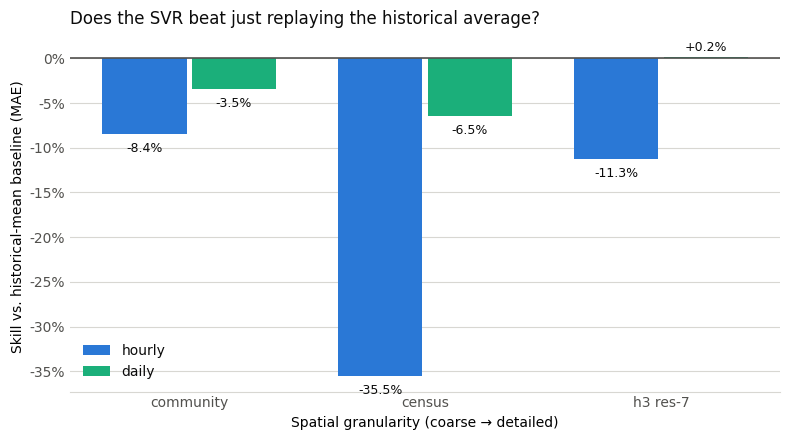

In [10]:
#| label: fig-svr-skill-by-level
#| fig-cap: "SVR skill against the historical-mean baseline, by spatial and temporal granularity."
plot_skill_by_level(level_comparison, title="Does the SVR beat just replaying the historical average?")

In [11]:
# Prediction on the test set and saving in parquet files for '3.4\ ModelPerformanceVisualization.ipynb' to evaluate
for spatial, temporal in LEVELS:
    print(f"\n{'-' * 70}\n{spatial} / {temporal}")
    df_test = load_splits(spatial, temporal)[2]
    key = SPATIAL_LEVELS[spatial]

    # Load the winner for this level
    best = joblib.load(SVR_DIR / spatial / temporal / "best.joblib")
    print(f"Loaded winner: {best['feature_set']} ({best['kernel']})")

    # Predict on the test split
    X_test = best["scaler"].transform(df_test[best["features"]])
    y_test_pred = to_counts(best["model"].predict(X_test))
    df_test["SVR_pred"] = y_test_pred

    # Save the predictions in parquet format for later evaluation in 3.4
    out_dir = MODELS_DIR / "predictions"
    out_dir.mkdir(parents=True, exist_ok=True)
    df_test.to_parquet(out_dir / f"test_pred_{spatial}_{temporal}.parquet", index=False)


----------------------------------------------------------------------
h3_7 / hourly
Loaded winner: basic (rbf)

----------------------------------------------------------------------
h3_7 / daily
Loaded winner: basic+poi (rbf)

----------------------------------------------------------------------
census / hourly
Loaded winner: basic+poi+weather (rbf)

----------------------------------------------------------------------
census / daily
Loaded winner: basic+poi (rbf)

----------------------------------------------------------------------
community / hourly
Loaded winner: basic+poi (rbf)

----------------------------------------------------------------------
community / daily
Loaded winner: basic+poi (rbf)


## 7. Feature Importance

Two complementary questions, which diverge exactly when features are substitutable:

| method | the question it answers |
|---|---|
| **Permutation importance** | Does the *fitted* model rely on this feature? (shuffle it, measure how much MAE degrades) |
| **Drop-column ablation** | Would a model *trained without* it be worse? (refit, compare) |

We report both, per feature block, as the **% increase in count-space MAE** — the metric the model
is actually judged on. A block worth 0% is one the model is not using. The heatmap below places the
two side by side; they disagree most on `base_demand`.

In [12]:
# Feature blocks. Columns inside a block are correlated with each other; columns across blocks are (mostly) not. 
FEATURE_BLOCKS = {
    "hour": HOUR,
    "calendar": CALENDAR,
    "location": LOCATION,
    "history (base_demand)": HISTORY,
    "poi": POI_COLS,
    "weather": WEATHER,
}

N_IMPORTANCE_ROWS = 8_000
N_REPEATS = 3

def _mae(bundle, X, y):
    """Count-space MAE of a bundle on an already-assembled feature frame."""
    return mean_absolute_error(y, to_counts(bundle["model"].predict(bundle["scaler"].transform(X))))

def permutation_importance(bundle, df_eval, groups, n_repeats=N_REPEATS, seed=RANDOM_STATE):
    """Increase in MAE when each group of columns is shuffled together."""
    rng = np.random.default_rng(seed)
    X = df_eval[bundle["features"]].copy()
    y = df_eval[TARGET].values
    baseline = _mae(bundle, X, y)

    rows = []
    # The groups dict may contain blocks that are not in this feature set, so filter them out.
    for name, cols in groups.items():
        cols = [c for c in cols if c in X.columns]
        if not cols:
            continue
        deltas = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[cols] = X[cols].to_numpy()[rng.permutation(len(X))]
            deltas.append(_mae(bundle, X_perm, y) - baseline)
        rows.append({
            "group": name,
            "n_cols": len(cols),
            "delta_MAE": float(np.mean(deltas)),
            "delta_MAE_std": float(np.std(deltas)),
            "pct_MAE_increase": float(np.mean(deltas)) / baseline * 100,
        })
    return pd.DataFrame(rows).sort_values("delta_MAE", ascending=False), baseline


def drop_column_ablation(bundle, df_train, df_eval, groups):
    """
    Refit the model without each block and measure how much worse validation MAE gets.
    Ablation asks whether a model trained without a feature would be worse. 

    The kernel and hyperparameters are held at the tuned values rather than re-searched, so the only
    thing that changes is the feature list.
    """
    y_eval = df_eval[TARGET].values
    params = {k: v for k, v in bundle["best_params"].items()}

    def fit_and_score(features):
        scaler = StandardScaler().fit(df_train[features])
        sample = balanced_sample(df_train, N_GRID)
        model = SVR(kernel=bundle["kernel"], cache_size=500, **params)
        model.fit(scaler.transform(sample[features]), np.log1p(sample[TARGET].values))
        pred = to_counts(model.predict(scaler.transform(df_eval[features])))
        return mean_absolute_error(y_eval, pred)

    full_mae = fit_and_score(bundle["features"])

    rows = []
    for name, cols in groups.items():
        remaining = [f for f in bundle["features"] if f not in cols]
        if len(remaining) == len(bundle["features"]) or not remaining:
            continue                                    # block absent, or would leave nothing
        mae = fit_and_score(remaining)
        rows.append({
            "dropped": name,
            "n_dropped": len(bundle["features"]) - len(remaining),
            "MAE_without": mae,
            "delta_MAE": mae - full_mae,
            "pct_MAE_increase": (mae - full_mae) / full_mae * 100,
        })
    return pd.DataFrame(rows).sort_values("delta_MAE", ascending=False), full_mae


In [13]:
# Run permutation importance + drop-column ablation on the WINNING model of each level. The splits
# are reloaded per level (ablation has to refit, so it needs the training data).

perm_block_rows = []    # blocks, permuted together
ablation_rows = []

for spatial, temporal in LEVELS:
    bundle = joblib.load(SVR_DIR / spatial / temporal / "best.joblib")
    df_train, df_val, _ = load_splits(spatial, temporal)
    df_eval = df_val.sample(n=min(N_IMPORTANCE_ROWS, len(df_val)), random_state=RANDOM_STATE)
    print(f"{spatial}/{temporal}: {bundle['feature_set']} ({len(bundle['features'])} features)")

    blocks, base_mae = permutation_importance(bundle, df_eval, FEATURE_BLOCKS)
    for r in blocks.to_dict("records"):
        perm_block_rows.append({"spatial": spatial, "temporal": temporal, **r})

    abl, full_mae = drop_column_ablation(bundle, df_train, df_eval, FEATURE_BLOCKS)
    for r in abl.to_dict("records"):
        ablation_rows.append({"spatial": spatial, "temporal": temporal, **r})

    top_perm = blocks.iloc[0]
    top_abl = abl.iloc[0]
    print(f"relies most on: {top_perm['group']} (+{top_perm['pct_MAE_increase']:.0f}% MAE shuffled)"
          f"  |  actually needs most: {top_abl['dropped']} (+{top_abl['pct_MAE_increase']:.1f}% MAE dropped)")

    del df_train, df_val, df_eval
    gc.collect()

# Kept as in-memory DataFrames only -- feature importance is a within-notebook diagnostic
# (feeds the heatmap below), nothing else reads these back, so no CSV is written.
perm_blocks = pd.DataFrame(perm_block_rows)
ablation = pd.DataFrame(ablation_rows)

# level x block matrices, consumed by the heatmap below
block_matrix = (perm_blocks
                .assign(level=perm_blocks.spatial + "/" + perm_blocks.temporal)
                .pivot(index="level", columns="group", values="pct_MAE_increase"))
ablation_matrix = (ablation
                   .assign(level=ablation.spatial + "/" + ablation.temporal)
                   .pivot(index="level", columns="dropped", values="pct_MAE_increase"))

h3_7/hourly: basic (12 features)
relies most on: history (base_demand) (+455% MAE shuffled)  |  actually needs most: history (base_demand) (+148.1% MAE dropped)
h3_7/daily: basic+poi (24 features)
relies most on: history (base_demand) (+515% MAE shuffled)  |  actually needs most: poi (+5.5% MAE dropped)
census/hourly: basic+poi+weather (31 features)
relies most on: history (base_demand) (+292% MAE shuffled)  |  actually needs most: history (base_demand) (+31.7% MAE dropped)
census/daily: basic+poi (24 features)
relies most on: poi (+2744% MAE shuffled)  |  actually needs most: poi (+9.4% MAE dropped)
community/hourly: basic+poi (26 features)
relies most on: history (base_demand) (+487% MAE shuffled)  |  actually needs most: history (base_demand) (+22.1% MAE dropped)
community/daily: basic+poi (24 features)
relies most on: history (base_demand) (+1412% MAE shuffled)  |  actually needs most: poi (+13.2% MAE dropped)


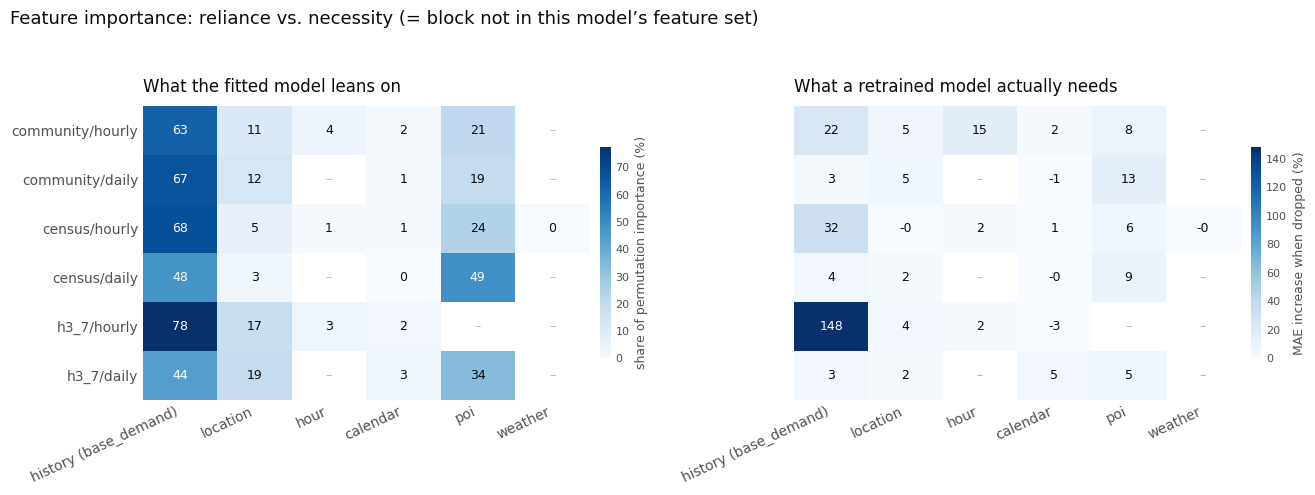

In [14]:
#| label: fig-svr-feature-importance
#| fig-cap: "Left: what the fitted model leans on (grouped permutation importance, as each block's share of the level's total). 
#| Right: what a retrained model actually needs (drop-column ablation, % increase in MAE when the block is removed). 
#| The two disagree sharply on base_demand — 
#| the fitted model depends on it almost entirely, yet a model refitted without it loses very little, because lat/lon/hour/day-of-week can reconstruct it."

BLOCK_ORDER = ["history (base_demand)", "location", "hour", "calendar", "poi", "weather"]
LEVEL_ORDER = [f"{s}/{t}" for s in ["community", "census", "h3_7"] for t in TEMPORAL_LEVELS]

# The permutation-importance matrix is normalized to show each block's share of the total, 
# so that the two matrices can be compared on the same scale.
share = (block_matrix
         .div(block_matrix.sum(axis=1), axis=0)
         .mul(100)
         .reindex(index=LEVEL_ORDER, columns=BLOCK_ORDER))
abl = ablation_matrix.reindex(index=LEVEL_ORDER, columns=BLOCK_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)

for ax, M, title, unit in [
    (axes[0], share, "What the fitted model leans on", "share of permutation importance (%)"),
    (axes[1], abl, "What a retrained model actually needs", "MAE increase when dropped (%)"),
]:
    A = M.to_numpy(dtype=float)
    im = ax.imshow(A, cmap="Blues", aspect="auto", vmin=0)      # sequential: one hue, light -> dark
    ax.set_xticks(np.arange(len(BLOCK_ORDER)), BLOCK_ORDER, rotation=25, ha="right")
    ax.tick_params(colors=MUTED, length=0)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)

    # Label every cell. The numbers are the finding, and a ramp alone cannot separate "small" from
    # "zero" -- which is precisely the distinction this figure exists to show.
    vmax = np.nanmax(A) if np.isfinite(A).any() else 1.0
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            v = A[i, j]
            if np.isnan(v):
                ax.text(j, i, "–", ha="center", va="center", color="#b8b7b2", fontsize=9)
            else:
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9,
                        color="#ffffff" if v > 0.55 * vmax else INK)

    cbar = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
    cbar.set_label(unit, color=MUTED, fontsize=9)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors=MUTED, length=0, labelsize=8)
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=10)

axes[0].set_yticks(np.arange(len(LEVEL_ORDER)), LEVEL_ORDER)

fig.suptitle("Feature importance: reliance vs. necessity (= block not in this model’s feature set)", color=INK, fontsize=13, x=0.01, ha="left")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()